# 🧠 Deep Learning - Partie 3: Application Pratique

## 🎯 Objectifs
- Appliquer les MLPs sur un dataset réel
- Comparer avec scikit-learn
- Techniques d'optimisation avancées
- Évaluation et métriques

---
*Session 05 - SupNum Nouakchott - Formation IA & Machine Learning*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("🚀 Prêt pour l'application pratique!")

🚀 Prêt pour l'application pratique!


## 📊 1. Chargement et exploration des données

Utilisons le dataset Breast Cancer de sklearn pour la classification.

In [2]:
def charger_donnees():
    """Charge et explore le dataset"""
    
    # Chargement du dataset
    data = load_breast_cancer()
    X, y = data.data, data.target
    
    print("🔍 EXPLORATION DU DATASET")
    print("="*40)
    print(f"Dataset: {data.DESCR.split('.')[0]}")
    print(f"Nombre d'échantillons: {X.shape[0]}")
    print(f"Nombre de features: {X.shape[1]}")
    print(f"Classes: {data.target_names}")
    print(f"Distribution: {np.bincount(y)}")
    
    # Création du DataFrame
    df = pd.DataFrame(X, columns=data.feature_names)
    df['target'] = y
    df['target_name'] = [data.target_names[i] for i in y]
    
    # Statistiques descriptives
    print(f"\n📈 Quelques statistiques:")
    print(df[['mean radius', 'mean texture', 'mean perimeter', 'target']].describe())
    
    return df, X, y, data

df, X, y, data = charger_donnees()

🔍 EXPLORATION DU DATASET
Dataset: 
Nombre d'échantillons: 569
Nombre de features: 30
Classes: ['malignant' 'benign']
Distribution: [212 357]

📈 Quelques statistiques:
       mean radius  mean texture  mean perimeter      target
count   569.000000    569.000000      569.000000  569.000000
mean     14.127292     19.289649       91.969033    0.627417
std       3.524049      4.301036       24.298981    0.483918
min       6.981000      9.710000       43.790000    0.000000
25%      11.700000     16.170000       75.170000    0.000000
50%      13.370000     18.840000       86.240000    1.000000
75%      15.780000     21.800000      104.100000    1.000000
max      28.110000     39.280000      188.500000    1.000000


## 🔧 2. Préparation des données

Normalisation et division train/test.

In [3]:
def preparer_donnees(X, y, test_size=0.2, random_state=42):
    """Prépare les données pour l'entraînement"""
    
    # Division train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Normalisation
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("📋 PRÉPARATION DES DONNÉES")
    print("="*30)
    print(f"Train: {X_train_scaled.shape[0]} échantillons")
    print(f"Test: {X_test_scaled.shape[0]} échantillons")
    print(f"Features: {X_train_scaled.shape[1]}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = preparer_donnees(X, y)

📋 PRÉPARATION DES DONNÉES
Train: 455 échantillons
Test: 114 échantillons
Features: 30


## 🧠 3. MLP amélioré avec techniques avancées

Version optimisée de notre MLP.

In [4]:
class MLPAvance:
    """MLP avec techniques avancées"""
    
    def __init__(self, layers, learning_rate=0.01, activation='relu', 
                 optimizer='adam', batch_size=32, dropout_rate=0.0):
        self.layers = layers
        self.learning_rate = learning_rate
        self.activation = activation
        self.optimizer = optimizer
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        
        # Initialisation des poids
        self.weights = []
        self.biases = []
        
        for i in range(len(layers)-1):
            # Initialisation Xavier/He
            if activation == 'relu':
                w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2.0/layers[i])
            else:
                w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(1.0/layers[i])
            
            self.weights.append(w)
            self.biases.append(np.zeros((1, layers[i+1])))
        
        # Pour Adam optimizer
        if optimizer == 'adam':
            self.m_w = [np.zeros_like(w) for w in self.weights]
            self.v_w = [np.zeros_like(w) for w in self.weights]
            self.m_b = [np.zeros_like(b) for b in self.biases]
            self.v_b = [np.zeros_like(b) for b in self.biases]
            self.beta1, self.beta2 = 0.9, 0.999
            self.epsilon = 1e-8
            self.t = 0
        
        # Historique
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []
    
    def relu(self, z):
        return np.maximum(0, z)
    
    def relu_derivative(self, z):
        return (z > 0).astype(float)
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        return z * (1 - z)
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def forward(self, X, training=True):
        """Propagation avant avec dropout"""
        self.activations = [X]
        
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            z = np.dot(self.activations[-1], w) + b
            
            if i == len(self.weights) - 1:  # Couche de sortie
                if len(np.unique(y)) == 2:  # Classification binaire
                    a = self.sigmoid(z)
                else:  # Classification multi-classe
                    a = self.softmax(z)
            else:  # Couches cachées
                if self.activation == 'relu':
                    a = self.relu(z)
                else:
                    a = self.sigmoid(z)
                
                # Dropout pendant l'entraînement
                if training and self.dropout_rate > 0:
                    dropout_mask = np.random.binomial(1, 1-self.dropout_rate, a.shape) / (1-self.dropout_rate)
                    a *= dropout_mask
            
            self.activations.append(a)
        
        return self.activations[-1]
    
    def backward(self, X, y_true, y_pred):
        """Rétropropagation avec optimiseurs avancés"""
        m = X.shape[0]
        
        # Gradient de la perte
        if len(np.unique(y)) == 2:  # Binaire
            dz = y_pred - y_true.reshape(-1, 1)
        else:  # Multi-classe
            y_one_hot = np.eye(len(np.unique(y)))[y_true]
            dz = y_pred - y_one_hot
        
        # Gradients
        dw_list = []
        db_list = []
        
        for i in reversed(range(len(self.weights))):
            dw = (1/m) * np.dot(self.activations[i].T, dz)
            db = (1/m) * np.sum(dz, axis=0, keepdims=True)
            
            dw_list.insert(0, dw)
            db_list.insert(0, db)
            
            if i > 0:  # Pas la première couche
                da = np.dot(dz, self.weights[i].T)
                if self.activation == 'relu':
                    dz = da * self.relu_derivative(self.activations[i])
                else:
                    dz = da * self.sigmoid_derivative(self.activations[i])
        
        # Mise à jour avec optimiseur
        if self.optimizer == 'adam':
            self.t += 1
            for i in range(len(self.weights)):
                # Moments
                self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * dw_list[i]
                self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * (dw_list[i] ** 2)
                self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * db_list[i]
                self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (db_list[i] ** 2)
                
                # Correction de biais
                m_w_corrected = self.m_w[i] / (1 - self.beta1 ** self.t)
                v_w_corrected = self.v_w[i] / (1 - self.beta2 ** self.t)
                m_b_corrected = self.m_b[i] / (1 - self.beta1 ** self.t)
                v_b_corrected = self.v_b[i] / (1 - self.beta2 ** self.t)
                
                # Mise à jour
                self.weights[i] -= self.learning_rate * m_w_corrected / (np.sqrt(v_w_corrected) + self.epsilon)
                self.biases[i] -= self.learning_rate * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)
        else:  # SGD classique
            for i in range(len(self.weights)):
                self.weights[i] -= self.learning_rate * dw_list[i]
                self.biases[i] -= self.learning_rate * db_list[i]
    
    def train(self, X_train, y_train, X_val=None, y_val=None, epochs=100, verbose=True):
        """Entraînement avec validation"""
        
        for epoch in range(epochs):
            # Mélange des données
            indices = np.random.permutation(len(X_train))
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            # Mini-batches
            for i in range(0, len(X_train), self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                
                # Forward et backward
                y_pred = self.forward(X_batch, training=True)
                self.backward(X_batch, y_batch, y_pred)
            
            # Évaluation
            if epoch % 10 == 0:
                train_pred = self.forward(X_train, training=False)
                train_loss = self.compute_loss(y_train, train_pred)
                train_acc = self.compute_accuracy(y_train, train_pred)
                
                self.train_losses.append(train_loss)
                self.train_accuracies.append(train_acc)
                
                if X_val is not None:
                    val_pred = self.forward(X_val, training=False)
                    val_loss = self.compute_loss(y_val, val_pred)
                    val_acc = self.compute_accuracy(y_val, val_pred)
                    
                    self.val_losses.append(val_loss)
                    self.val_accuracies.append(val_acc)
                    
                    if verbose:
                        print(f"Époque {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.3f}, "
                              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.3f}")
                else:
                    if verbose:
                        print(f"Époque {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.3f}")
    
    def compute_loss(self, y_true, y_pred):
        """Calcule la perte"""
        if len(np.unique(y)) == 2:  # Binaire
            return -np.mean(y_true * np.log(y_pred + 1e-15) + (1-y_true) * np.log(1-y_pred + 1e-15))
        else:  # Multi-classe
            y_one_hot = np.eye(len(np.unique(y)))[y_true]
            return -np.mean(np.sum(y_one_hot * np.log(y_pred + 1e-15), axis=1))
    
    def compute_accuracy(self, y_true, y_pred):
        """Calcule la précision"""
        if len(np.unique(y)) == 2:  # Binaire
            predictions = (y_pred > 0.5).astype(int).flatten()
        else:  # Multi-classe
            predictions = np.argmax(y_pred, axis=1)
        return np.mean(predictions == y_true)
    
    def predict(self, X):
        """Prédictions"""
        y_pred = self.forward(X, training=False)
        if len(np.unique(y)) == 2:  # Binaire
            return (y_pred > 0.5).astype(int).flatten()
        else:  # Multi-classe
            return np.argmax(y_pred, axis=1)

print("✅ MLP avancé implémenté!")

✅ MLP avancé implémenté!


## 🎯 4. Entraînement et comparaison

Comparons notre MLP avec scikit-learn.

In [5]:
def comparer_modeles():
    """Compare notre MLP avec sklearn"""
    
    print("🏁 COMPARAISON DES MODÈLES")
    print("="*30)
    
    # Notre MLP
    print("Entraînement de notre MLP...")
    mlp_custom = MLPAvance(
        layers=[X_train.shape[1], 64, 32, 1],
        learning_rate=0.001,
        activation='relu',
        optimizer='adam',
        batch_size=32,
        dropout_rate=0.1
    )
    
    mlp_custom.train(X_train, y_train, X_test, y_test, epochs=200, verbose=False)
    
    # Prédictions
    y_pred_custom = mlp_custom.predict(X_test)
    acc_custom = accuracy_score(y_test, y_pred_custom)
    
    # Sklearn MLP
    print("Entraînement du MLP sklearn...")
    mlp_sklearn = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42
    )
    
    mlp_sklearn.fit(X_train, y_train)
    y_pred_sklearn = mlp_sklearn.predict(X_test)
    acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
    
    # Résultats
    print(f"\n📊 RÉSULTATS:")
    print(f"Notre MLP:     {acc_custom:.4f}")
    print(f"Sklearn MLP:   {acc_sklearn:.4f}")
    
    return mlp_custom, mlp_sklearn, y_pred_custom, y_pred_sklearn

mlp_custom, mlp_sklearn, y_pred_custom, y_pred_sklearn = comparer_modeles()

🏁 COMPARAISON DES MODÈLES
Entraînement de notre MLP...
Entraînement du MLP sklearn...

📊 RÉSULTATS:
Notre MLP:     0.9561
Sklearn MLP:   0.9649


## 📈 5. Visualisation des résultats

Analysons les performances en détail.

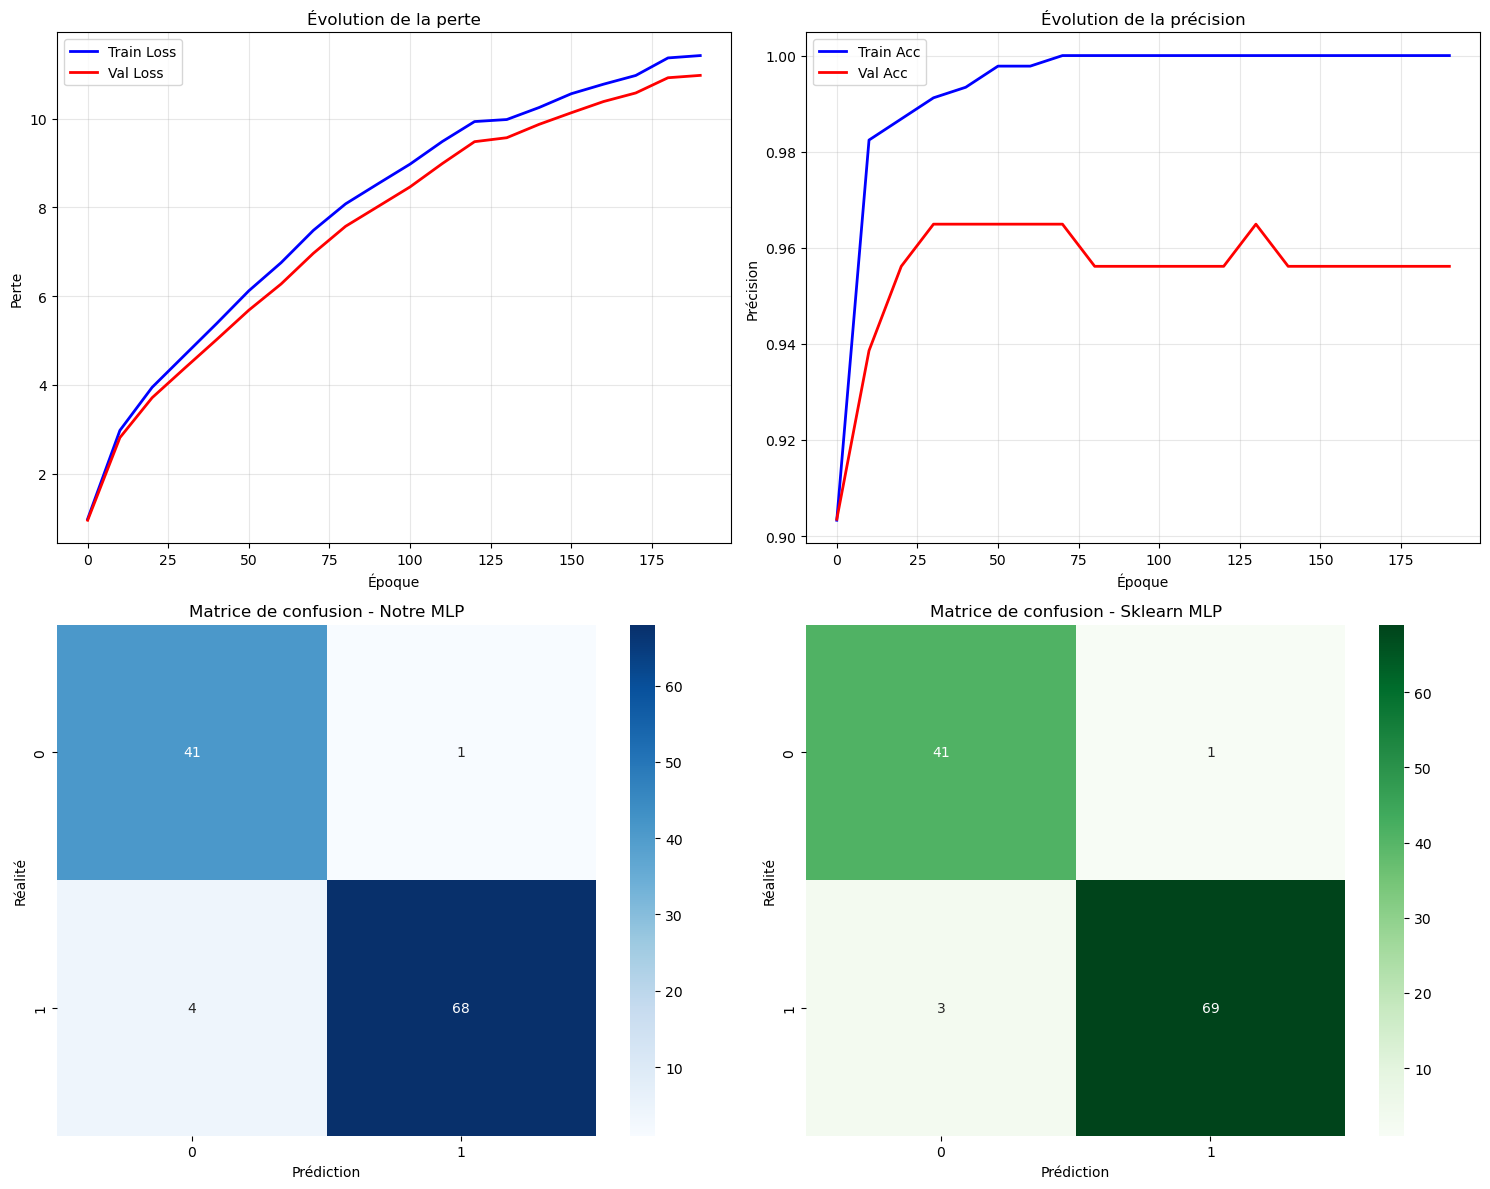

📋 RAPPORT DÉTAILLÉ - Notre MLP
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


📋 RAPPORT DÉTAILLÉ - Sklearn MLP
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [6]:
def visualiser_resultats(mlp_custom, mlp_sklearn, y_pred_custom, y_pred_sklearn):
    """Visualise les résultats de comparaison"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Courbes d'apprentissage
    ax1 = axes[0, 0]
    epochs_plot = range(0, len(mlp_custom.train_losses) * 10, 10)
    
    ax1.plot(epochs_plot, mlp_custom.train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs_plot, mlp_custom.val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Perte')
    ax1.set_title('Évolution de la perte')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Précision
    ax2 = axes[0, 1]
    ax2.plot(epochs_plot, mlp_custom.train_accuracies, 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs_plot, mlp_custom.val_accuracies, 'r-', label='Val Acc', linewidth=2)
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Précision')
    ax2.set_title('Évolution de la précision')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Matrice de confusion - Notre MLP
    ax3 = axes[1, 0]
    cm_custom = confusion_matrix(y_test, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=ax3)
    ax3.set_title('Matrice de confusion - Notre MLP')
    ax3.set_xlabel('Prédiction')
    ax3.set_ylabel('Réalité')
    
    # 4. Matrice de confusion - Sklearn
    ax4 = axes[1, 1]
    cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
    sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=ax4)
    ax4.set_title('Matrice de confusion - Sklearn MLP')
    ax4.set_xlabel('Prédiction')
    ax4.set_ylabel('Réalité')
    
    plt.tight_layout()
    plt.show()
    
    # Rapports détaillés
    print("📋 RAPPORT DÉTAILLÉ - Notre MLP")
    print("="*35)
    print(classification_report(y_test, y_pred_custom, target_names=data.target_names))
    
    print("\n📋 RAPPORT DÉTAILLÉ - Sklearn MLP")
    print("="*35)
    print(classification_report(y_test, y_pred_sklearn, target_names=data.target_names))

visualiser_resultats(mlp_custom, mlp_sklearn, y_pred_custom, y_pred_sklearn)

## 🎮 6. Interface interactive pour expérimenter

Testez différentes architectures et hyperparamètres.

In [ ]:
@interact(
    hidden_layers=Dropdown(options=['[32]', '[64, 32]', '[128, 64, 32]', '[256, 128, 64]'], 
                          value='[64, 32]', description='Architecture:'),
    learning_rate=FloatSlider(min=0.0001, max=0.01, step=0.0001, value=0.001, description='Learning Rate:'),
    dropout_rate=FloatSlider(min=0.0, max=0.5, step=0.1, value=0.1, description='Dropout:'),
    optimizer=Dropdown(options=['adam', 'sgd'], value='adam', description='Optimiseur:'),
    epochs=IntSlider(min=50, max=300, step=50, value=200, description='Époques:')
)
def mlp_interactif_reel(hidden_layers, learning_rate, dropout_rate, optimizer, epochs):
    """Interface pour tester différentes configurations"""
    
    # Parse architecture
    hidden = eval(hidden_layers)
    layers = [X_train.shape[1]] + hidden + [1]
    
    print(f"🔧 Configuration: {layers}")
    print(f"📊 Entraînement en cours...")
    
    # Entraînement
    mlp = MLPAvance(
        layers=layers,
        learning_rate=learning_rate,
        optimizer=optimizer,
        dropout_rate=dropout_rate,
        batch_size=32
    )
    
    mlp.train(X_train, y_train, X_test, y_test, epochs=epochs, verbose=False)
    
    # Évaluation
    y_pred = mlp.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Courbes d'apprentissage
    epochs_plot = range(0, len(mlp.train_losses) * 10, 10)
    ax1.plot(epochs_plot, mlp.train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs_plot, mlp.val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Perte')
    ax1.set_title('Courbes d\'apprentissage')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title(f'Matrice de confusion (Acc: {accuracy:.3f})')
    ax2.set_xlabel('Prédiction')
    ax2.set_ylabel('Réalité')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Précision finale: {accuracy:.4f}")
    print(f"📈 Meilleure val accuracy: {max(mlp.val_accuracies):.4f}")

## 🎓 Résumé - Application Pratique

### ✅ Ce que nous avons appris:
- Application sur données réelles
- Techniques d'optimisation (Adam, dropout)
- Comparaison avec bibliothèques professionnelles
- Évaluation complète des performances

### 🚀 Techniques avancées utilisées:
- **Initialisation Xavier/He** pour de meilleurs poids initiaux
- **Optimiseur Adam** pour convergence plus rapide
- **Dropout** pour éviter le surapprentissage
- **Mini-batches** pour efficacité computationnelle

### 💡 Points clés:
- Les MLPs sont efficaces sur des données tabulaires
- L'optimisation des hyperparamètres est cruciale
- La validation croisée aide à éviter le surapprentissage
- Les bibliothèques comme sklearn sont très optimisées

**🎉 Félicitations !** Vous maîtrisez maintenant les bases du Deep Learning !